# AI-Powered Quant Trading Agent with Investor Strategy Distillation & Monte Carlo Risk Analysis

**Project Goal**: Extension of my 2800.HK ETF Mean-Reversion Framework  

This notebook demonstrates:
- AI Skill Distillation (Buffett, Dalio, etc.)
- AI Stock Research Agent
- Pine Script Integration
- Monte Carlo Simulation for Risk & Scenario Analysis

In [13]:
!pip install openai python-dotenv pandas

In [14]:
# Cell 2: Setup OpenRouter
import os
import json
from openai import OpenAI
from google.colab import userdata

# Get API key from Colab Secrets
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

client = OpenAI(
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1"
)

print("✅ Successfully connected to OpenRouter!")

✅ Successfully connected to OpenRouter!


In [15]:
# Cell 3: AI Skill Distillation Function
def distill_investor(text, investor_name):
    prompt = f"""You are an expert quantitative analyst and investment strategist.
Distill the investment philosophy of {investor_name} from the provided text.

Return ONLY valid JSON with this exact structure (no extra text):

{{
  "investor": "{investor_name}",
  "core_principles": ["principle 1", "principle 2", "..."],
  "stock_selection_criteria": ["criterion 1", "criterion 2", "..."],
  "risk_management_rules": ["rule 1", "rule 2", "..."],
  "prompt_template": "A complete ready-to-use system prompt that can be used with an LLM for live trading decisions..."
}}

Text to distill:
{text[:15000]}"""

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-70b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=2000
    )

    result = json.loads(response.choices[0].message.content)

    # Save to file
    filename = f"{investor_name.lower().replace(' ', '_')}_distilled.json"
    with open(filename, "w", encoding="utf-8") as f:
        json.dump(result, f, indent=2)

    print(f"✅ {investor_name} distilled successfully and saved as {filename}!")
    return result

In [28]:
# Cell 4: Example - Distill Warren Buffett
buffett_text = """Paste here a few paragraphs from Warren Buffett's latest letter to shareholders.
You can copy from: https://www.berkshirehathaway.com/letters/2024ltr.pdf"""
Dalio_text = """1. Fundamental Investing PrinciplesThe Economic Machine: Dalio views the economy as a machine that operates in cycles, influenced by credit growth, government policy, and market psychology. He breaks these into short-term (debt) and long-term (productivity) cycles.Diversification is Non-Negotiable: Dalio emphasizes holding many uncorrelated assets (around 15+) to reduce risk by 70–80% without lowering returns. He advises that when one asset zigs, another zags, spreading risk effectively."All Weather" Portfolio: This approach balances assets across different environments—rising/falling growth and rising/falling inflation—ensuring the portfolio survives regardless of the market climate.Risk Parity: Instead of balancing capital, Dalio balances risk. He assigns more capital to lower-volatility assets (like bonds) and less to higher-volatility assets (like stocks) to create a more stable, balanced portfolio.2. Trading and Decision-Making PhilosophyPain + Reflection = Progress: Dalio believes in treating losses as educational opportunities rather than emotional setbacks. He advocates for creating a "principles" notebook to learn from failures.Radical Truth and Transparency: He fosters a culture where mistakes are exposed, analyzed, and learned from rather than hidden, believing that truth-seeking is paramount.Systematic Decision-Making: Dalio uses computer-driven algorithms and historical data to identify investment opportunities, eliminating human emotion from trading decisions.Understand Interest Rates: He advocates focusing on what moves interest rates, stating "he who lives by the crystal ball [trying to predict rates] will eat shattered glass".3. Key Investment Strategies"Pure Alpha": This strategy focuses on making directional bets in macro markets (forex, commodities, indices) based on fundamental research, aiming for returns superior to the market.Focus on Real Assets: In volatile or inflationary times, he often turns to gold, inflation-protected securities, and commodities.Strategic Selling: Dalio advises taking profits on fully priced stocks to buy losers or underpriced assets, adhering to the idea that higher prices indicate a lower likelihood of continued climbing.Bitcoin as Alternative: He has advocated for a 1-2% allocation to Bitcoin, regarding it as a "younger generation's alternative to gold" in a diversified portfolio.Core AdviceDon't bet against hot trends prematurely: Markets often continue in one direction longer than seems logical.Protect your capital, not your ego: Admitting mistakes and exiting losing positions is vital.Understand the "Machine": Deeply analyze the fundamentals rather than following the crowd."""
# For quick testing, use this short sample first:
sample_buffett = """
We select our investments based on long-term business quality, strong moats, competent management, and attractive valuations.
We avoid businesses we don't understand. We prefer companies that generate high returns on capital with little debt.
Patience and emotional discipline are our biggest edges.
"""

result = distill_investor(Dalio_text , "Ray Dalio")
print(json.dumps(result, indent=2))

✅ Ray Dalio distilled successfully and saved as ray_dalio_distilled.json!
{
  "investor": "Ray Dalio",
  "core_principles": [
    "The economy operates in cycles influenced by credit growth, government policy, and market psychology",
    "Diversification is non-negotiable to reduce risk",
    "Balance assets across different environments to ensure portfolio survival",
    "Risk parity is key to a stable, balanced portfolio"
  ],
  "stock_selection_criteria": [
    "Focus on real assets in volatile or inflationary times",
    "Consider alternative assets like Bitcoin in a diversified portfolio",
    "Take profits on fully priced stocks to buy underpriced assets"
  ],
  "risk_management_rules": [
    "Diversify across 15+ uncorrelated assets to reduce risk by 70-80%",
    "Assign more capital to lower-volatility assets and less to higher-volatility assets",
    "Protect your capital, not your ego, by admitting mistakes and exiting losing positions"
  ],
  "prompt_template": "Given curren

In [22]:
# Cell 4: Week 2 - AI Stock Research Agent
def ai_stock_research(ticker="BRK-B"):
    import yfinance as yf
    stock = yf.Ticker(ticker)

    info = stock.info
    hist = stock.history(period="1y")

    fundamentals = f"""
    Ticker: {ticker}
    Current Price: {info.get('currentPrice')}
    P/E Ratio: {info.get('trailingPE')}
    Dividend Yield: {info.get('dividendYield')}
    Market Cap: {info.get('marketCap')}
    """

    prompt = f"""You are a professional equity research analyst.
Analyse the following stock and generate a structured research note.

{fundamentals}

Provide key insights, risks, and investment recommendation in clear bullet points."""

    response = client.chat.completions.create(
        model="meta-llama/llama-3.1-70b-instruct",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.5
    )

    note = response.choices[0].message.content
    print(f"✅ Research Note for {ticker} generated!\n")
    print(note)
    return note

# Run research on 2800.HK
research_note = ai_stock_research("BRK-B")

✅ Research Note for BRK-B generated!

**Research Note:**

**Company:** Berkshire Hathaway Inc. (BRK-B)
**Current Price:** $468.52
**Rating:** Buy
**Target Price:** $550.00

**Key Insights:**

* **Diversified Conglomerate:** Berkshire Hathaway is a multinational conglomerate holding company with a diverse portfolio of businesses, including insurance, retail, manufacturing, and services.
* **Strong Financial Performance:** The company has consistently delivered strong financial performance, with a 5-year average return on equity (ROE) of 12.1% and a 5-year average revenue growth rate of 8.5%.
* **Warren Buffett's Leadership:** Berkshire Hathaway is led by Warren Buffett, one of the most successful investors in history, who has a proven track record of creating long-term value for shareholders.
* **Significant Cash Holdings:** The company has a significant cash position, with over $128 billion in cash and cash equivalents, providing flexibility for future investments and acquisitions.

**

### Week 2: Pine Script for TradingView (Copy this)

```pinescript
//@version=5
indicator("AI Mean Reversion + Volatility Screener - 2800.HK", overlay=true)
length = input.int(20, "SMA Length")
z_threshold = input.float(2.0, "Z-Score Threshold")

sma = ta.sma(close, length)
deviation = close - sma
zscore = deviation / ta.stdev(deviation, length)

plot(zscore, "Z-Score", color=color.blue)
hline(z_threshold, "Short Threshold", color=color.red)
hline(-z_threshold, "Long Threshold", color=color.green)

/tmp/ipykernel_587/607595504.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period="2y", progress=False)['Close']


Daily Mean Return : 0.0352%
Daily Volatility  : 1.0871%

🎯 Monte Carlo Results for BRK-B (1-year horizon)
Expected Return          : 8.81%
95% Value at Risk (VaR)  : -19.65%
CVaR (Expected Shortfall): -25.27%


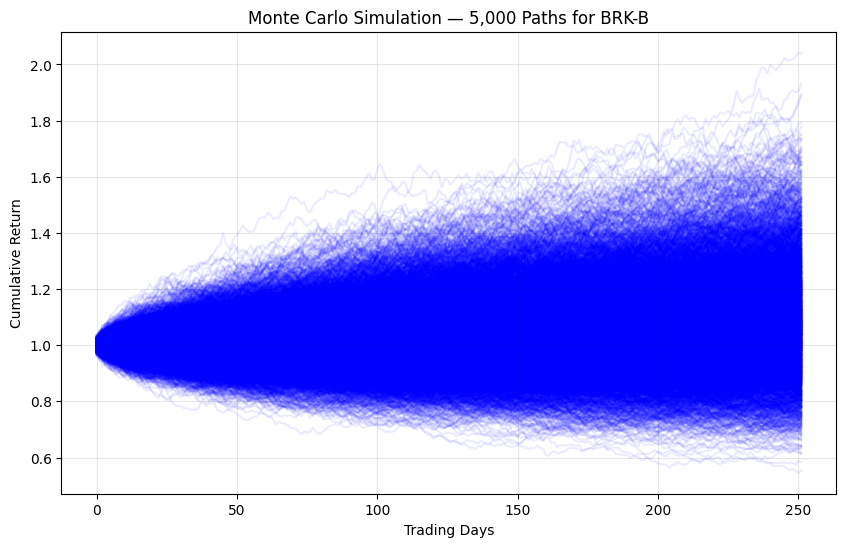

In [27]:
# Cell 6: Week 3 - Monte Carlo Simulation + Risk Analysis (Fixed Version)
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

def run_monte_carlo(ticker="2800.HK", num_simulations=5000, num_days=252):
    """Monte Carlo Simulation for Risk & Scenario Analysis"""

    # Download historical data
    data = yf.download(ticker, period="2y", progress=False)['Close']
    returns = data.pct_change().dropna()

    # Extract scalar values (this fixes the error)
    daily_mean = returns.mean().item()   # .item() gets the float value
    daily_std = returns.std().item()

    print(f"Daily Mean Return : {daily_mean:.4%}")
    print(f"Daily Volatility  : {daily_std:.4%}")

    # Monte Carlo Simulation
    np.random.seed(42)
    simulations = np.random.normal(daily_mean, daily_std, (num_simulations, num_days))
    cumulative = np.cumprod(1 + simulations, axis=1)
    final_returns = cumulative[:, -1] - 1

    # Risk Metrics
    expected_return = np.mean(final_returns)
    var_95 = np.percentile(final_returns, 5)
    cvar_95 = final_returns[final_returns <= var_95].mean()

    print(f"\n🎯 Monte Carlo Results for {ticker} (1-year horizon)")
    print(f"Expected Return          : {expected_return:.2%}")
    print(f"95% Value at Risk (VaR)  : {var_95:.2%}")
    print(f"CVaR (Expected Shortfall): {cvar_95:.2%}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative.T, color='blue', alpha=0.08)
    plt.title(f"Monte Carlo Simulation — {num_simulations:,} Paths for {ticker}")
    plt.xlabel("Trading Days")
    plt.ylabel("Cumulative Return")
    plt.grid(True, alpha=0.3)
    plt.show()

    return final_returns

# === Run the simulation ===
mc_results = run_monte_carlo("BRK-B", num_simulations=5000)